In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfilt

import sys
sys.path.append('../../')
import analysis_utils as utils
import calc_gas_collision_spectrum as calc_gas

utils.load_plotting_setting()

In [3]:
import os
import glob
import scipy.io

DATA_DIR = '/Volumes/LaCie/electric_feedback/sphere_20260215'

# Collect all 20260305_d_* folders, sorted by label
folder_names = sorted([
    d for d in os.listdir(DATA_DIR)
    if d.startswith('20260305_d_') and os.path.isdir(os.path.join(DATA_DIR, d))
])

# Define a sort key to order by dB level where possible
def sort_key(name):
    tag = name.replace('20260305_d_', '')
    if tag == 'pllonly':
        return (1, 0, 0)
    if tag.startswith('pll_'):
        db_str = tag.replace('pll_', '').replace('db', '')
        return (2, float(db_str), 0)
    parts = tag.replace('db', '').split('_')
    vals = [float(p) for p in parts if p]
    return (0, vals[0], vals[1] if len(vals) > 1 else 0)

folder_names = sorted(folder_names, key=sort_key)

for fn in folder_names:
    mats = sorted(glob.glob(os.path.join(DATA_DIR, fn, '*.mat')))
    print(f'{fn}: {len(mats)} files')

20260305_d_-40db: 5 files
20260305_d_-30db: 5 files
20260305_d_-20db: 5 files
20260305_d_-10db: 5 files
20260305_d_0db: 5 files
20260305_d_10db: 5 files
20260305_d_10db_40db: 5 files
20260305_d_20db: 5 files
20260305_d_30db: 5 files
20260305_d_40db: 5 files
20260305_d_pllonly: 5 files
20260305_d_pll_-40db: 5 files


In [50]:
def load_mat_channel(filepath):
    """Load D channel from a .mat file, returning (dt, data_1d)."""
    d = scipy.io.loadmat(filepath)
    dt = float(d['Tinterval'].ravel()[0])
    data = d['D'].ravel().astype(np.float64)
    return dt, data


# Compute PSD for each folder using only the first file
NPERSEG = 2**18  # ~52 ms segments at 5 MHz

psds = {}   # folder_name -> (ff, pp)

for fn in folder_names:
    mat_files = sorted(glob.glob(os.path.join(DATA_DIR, fn, '*.mat')))
    dt, zz = load_mat_channel(mat_files[0])
    ff, pp = utils.get_psd(dt=dt, zz=zz, nperseg=NPERSEG)
    psds[fn] = (ff, pp)
    print(f'Done: {fn}')

Done: 20260305_d_-40db
Done: 20260305_d_-30db
Done: 20260305_d_-20db
Done: 20260305_d_-10db
Done: 20260305_d_0db
Done: 20260305_d_10db
Done: 20260305_d_10db_40db
Done: 20260305_d_20db
Done: 20260305_d_30db
Done: 20260305_d_40db
Done: 20260305_d_pllonly
Done: 20260305_d_pll_-40db


In [56]:
CAL_DIR = '/Volumes/LaCie/electric_feedback/sphere_20260215/20260305_electric_calibration_3e-8mbar_0'
CAL_PREFIX = '20260305_d_p5e_117khz'
CAL_SUFFIX = 'lensholder1'
VPPS = [0.5, 1, 1.5, 2]

c_mvs_all = []
for vpp in VPPS:
    files = sorted(glob.glob(os.path.join(CAL_DIR, f'{CAL_PREFIX}_{vpp}vpp_{CAL_SUFFIX}_*.hdf5')))
    c_mv_arr = utils.get_c_mv(
        files,
        vp2p=[vpp] * len(files),
        omegad=117000 * 2 * np.pi,
        passband=(116900, 117100),
        searchband=(38000, 75000),
        charge=5,
        efield=138,
        sphere_radius=50e-9,
        n_chunk=1,
    )
    c_mvs_all.append(c_mv_arr)
    print(f'{vpp} Vpp: c_mv = {np.mean(c_mv_arr):.4e} m/V')

c_mv = np.mean(np.asarray(c_mvs_all))
print(f'\nMean c_mv = {c_mv:.4e} m/V')

0.5 Vpp: c_mv = 8.2671e-07 m/V
1 Vpp: c_mv = 5.0829e-07 m/V
1.5 Vpp: c_mv = 5.1387e-07 m/V
2 Vpp: c_mv = 5.1855e-07 m/V

Mean c_mv = 5.9185e-07 m/V


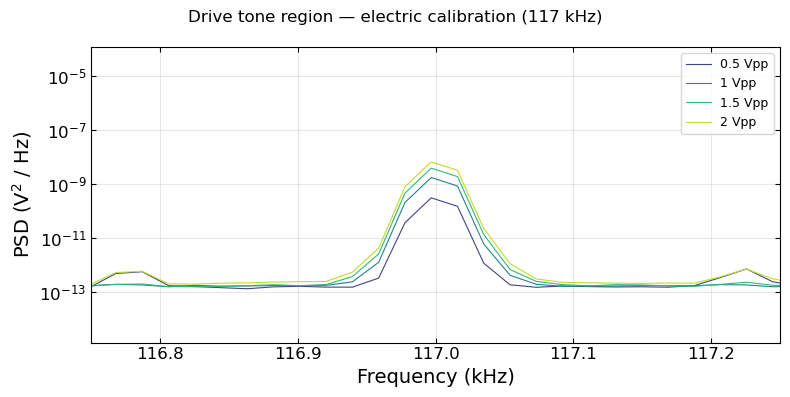

In [55]:
# Plot PSD near 117 kHz drive tone for one file per voltage, to guide passband choice
fig, ax = plt.subplots(figsize=(8, 4))

colors_cal = plt.colormaps['viridis'](np.linspace(0.2, 0.9, len(VPPS)))
for i, vpp in enumerate(VPPS):
    files = sorted(glob.glob(os.path.join(CAL_DIR, f'{CAL_PREFIX}_{vpp}vpp_{CAL_SUFFIX}_*.hdf5')))
    dtt, nn = utils.load_timestreams(files[0], ['D'])
    ff, pp = utils.get_psd(dt=dtt, zz=nn[0], nperseg=2**18)
    ax.semilogy(ff / 1e3, pp, lw=0.8, label=f'{vpp} Vpp', color=colors_cal[i])

ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel('PSD (V$^2$ / Hz)')
ax.set_xlim(116.75, 117.25)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
fig.suptitle('Drive tone region — electric calibration (117 kHz)')
fig.tight_layout()
plt.show()

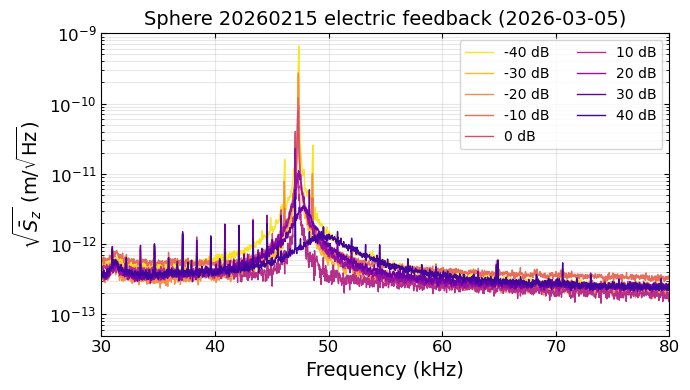

In [59]:
def make_label(folder_name):
    tag = folder_name.replace('20260305_d_', '')
    return tag.replace('db', ' dB')


plot_folders = [
    fn for fn in folder_names
    if 'pll' not in fn and '10db_40db' not in fn
]

colors = plt.colormaps['plasma'](np.linspace(0.95, 0.1, len(plot_folders)))
fig, ax = plt.subplots(figsize=(7, 4))

for i, fn in enumerate(plot_folders):
    ff, pp = psds[fn]
    label = make_label(fn)
    ax.plot(ff / 1e3, np.sqrt(pp * c_mv**2), lw=1, label=label, color=colors[i], linestyle='-')

ax.set_yscale('log')
ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel(r'$\sqrt{\bar{S}_z}$ (m/$\sqrt{\mathrm{Hz}}$)')
ax.set_title('Sphere 20260215 electric feedback (2026-03-05)')
ax.set_xlim(30, 80)
ax.set_ylim(5e-14, 1e-9)

ax.legend(fontsize=10, ncol=2)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

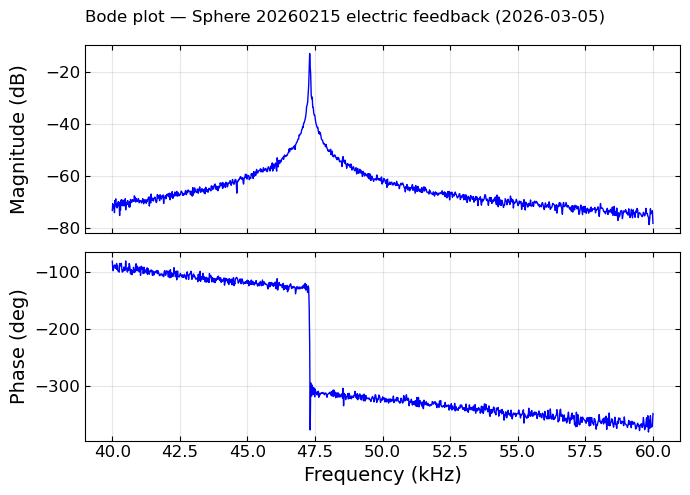

In [39]:
bode_file = '/Volumes/LaCie/electric_feedback/sphere_20260215/MokuFrequencyResponseAnalyzerSlot3Data_20260305_172513_Traces.csv'
bode_data = np.genfromtxt(bode_file, delimiter=',', comments='%')
bode_freq, bode_mag_db, bode_phase_deg = bode_data[:, 0], bode_data[:, 1], bode_data[:, 2]

fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)

axes[0].plot(bode_freq / 1e3, bode_mag_db, lw=1, color='b')
axes[0].set_ylabel('Magnitude (dB)')
axes[0].grid(True, which='both', alpha=0.3)

axes[1].plot(bode_freq / 1e3, bode_phase_deg, lw=1, color='b')
axes[1].set_ylabel('Phase (deg)')
axes[1].set_xlabel('Frequency (kHz)')
axes[1].grid(True, which='both', alpha=0.3)

fig.suptitle('Bode plot — Sphere 20260215 electric feedback (2026-03-05)')
fig.tight_layout()
fig.align_labels()
plt.show()